## 01 Import Data

### 01-1 Setup Config

In [24]:
from dotenv import load_dotenv
import os
import json
load_dotenv()
POSTGRES_URI = os.getenv('POSTGRES_URI')

# Set the stock code you want to analyze
STOCK_CODE = 2303

map_dict_path = '/app/data/column_mapping.json'
with open(map_dict_path, 'r', encoding='utf-8') as f:
    map_dict = json.load(f)
# '6770', '2337', '2344', '2303', '2408', '2515', '5521', '2542', '1316', '2442', '2485', '6285', '2455', '2412', '4977', '2367', '2313', '3037', '4958', '2327'

In [39]:
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score
from collections import defaultdict
import math

%matplotlib inline

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

Colour_Palette = ['#01BEFE', '#FF7D00', '#FFDD00', '#FF006D', '#ADFF02', '#8F00FF']
sns.set_palette(sns.color_palette(Colour_Palette))

tqdm.pandas()

### 01-2 Load Data

In [56]:
def get_stock_data(stock_code, start_date: str, end_date: str, return_all=False):
    # Fetch data from PostgreSQL database
    table_name = f'daily_info_{stock_code}'
    query = f"""
    SELECT *
    FROM {table_name}
    WHERE 股票代號 = '{stock_code}'
      AND 日期 BETWEEN '{start_date}' AND '{end_date}'
    ORDER BY 日期 ASC;
    """
    df = pd.read_sql(query, POSTGRES_URI)

    # Rename columns using the mapping dictionary
    df.rename(columns=map_dict, inplace=True)
    return df

df = get_stock_data(STOCK_CODE, '2025-02-01', '2026-02-28')
df.head()

,date,trading_volume,trading_value,open,high,low,close,price_change,transaction_count,note,stock_code
0,2025-02-03,112511997,4559923873,40.20,41.65,40.00,40.50,0.30,34801,,2303
1,2025-02-04,58336092,2350280013,40.95,40.95,40.10,40.10,-0.40,21867,,2303
2,2025-02-05,34136699,1373735533,40.40,40.65,40.10,40.10,0.00,15408,,2303
3,2025-02-06,32830275,1315951545,40.30,40.35,39.95,40.10,0.00,14523,,2303
4,2025-02-07,23231817,933331954,40.10,40.30,40.10,40.15,0.05,8946,,2303


In [ ]:
# Fill null values in 'price_change' using the values from 'price_change_new' (today's close - yesterday's close)
df['price_change_new'] = df['close']-df['close'].shift(1)
df['price_change'] = df['price_change'].fillna(df['price_change_new'])
df = df.drop(columns=['price_change_new'])
df.isnull().sum()

date                 0
trading_volume       0
trading_value        0
open                 0
high                 0
low                  0
close                0
price_change         0
transaction_count    0
note                 0
stock_code           0
dtype: int64

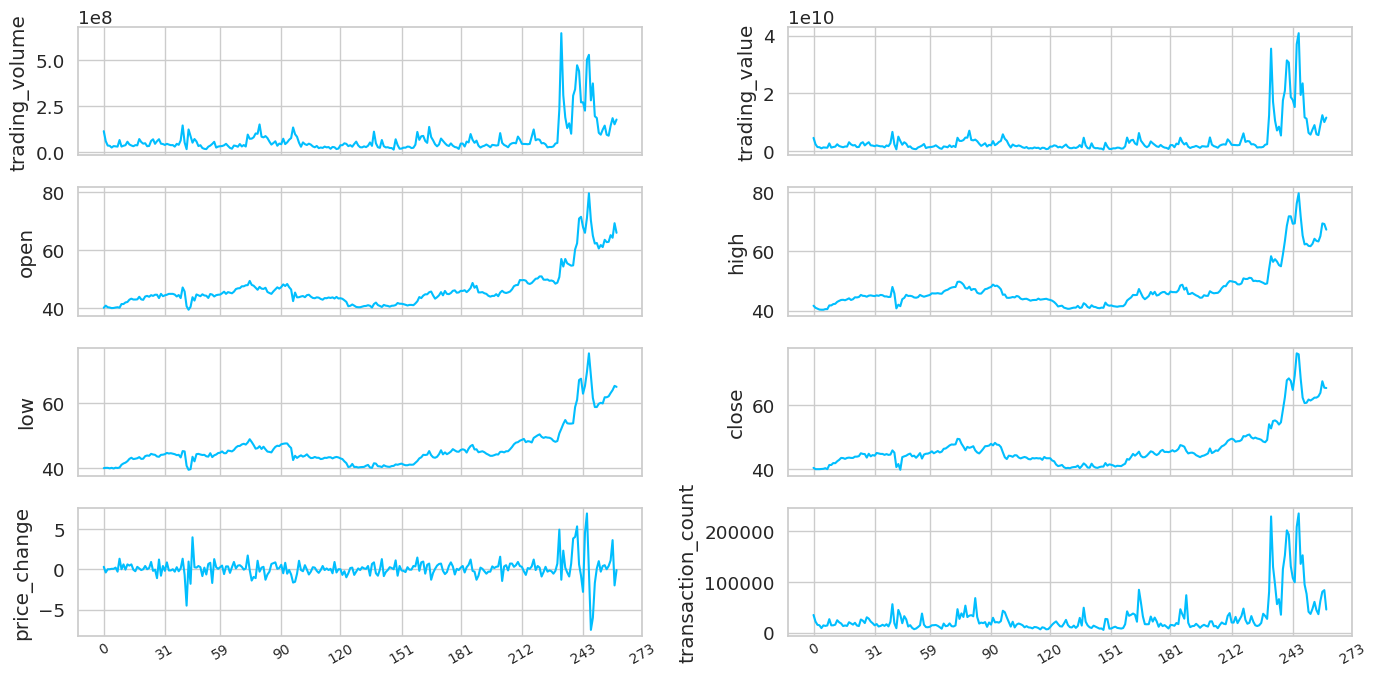

In [58]:
def data_plot(df):
    # Plot line charts
    df_plot = df.drop(columns=['note', 'stock_code', 'date'])

    ncols = 2
    nrows = int(round(df_plot.shape[1] / ncols, 0))

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(14, 7))
    for i, ax in enumerate(fig.axes):
        sns.lineplot(data=df_plot.iloc[:, i], ax=ax)
        ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.tight_layout()
    plt.show()

data_plot(df)

### 01-3 Feature Engineering

In [86]:
# Train test split
train_ratio = 0.8
validation_ratio = 0.1
test_ratio = 1 - train_ratio - validation_ratio
predict_col = 'price_change'

df_X_train, df_X_test, df_y_train, df_y_test = train_test_split(
    df.drop(columns=[predict_col]), 
    df[predict_col], 
    test_size=1-train_ratio, 
    shuffle=False
)
df_X_val, df_X_test, df_y_val, df_y_test = train_test_split(
    df_X_test, 
    df_y_test, 
    test_size=test_ratio/(test_ratio + validation_ratio), 
    shuffle=False
)
print(f"Train set: {df_X_train.shape[0]} samples")
print(f"Validation set: {df_X_val.shape[0]} samples")
print(f"Test set: {df_X_test.shape[0]} samples")

Train set: 208 samples
Validation set: 26 samples
Test set: 27 samples


In [87]:
# Reshape and scale data
scaler = MinMaxScaler(feature_range=(0, 1))
df_X_train_scaled = scaler.fit_transform(
    df_X_train.drop(columns=['date', 'stock_code', 'note'])
)
df_X_val_scaled = scaler.transform(
    df_X_val.drop(columns=['date', 'stock_code', 'note'])
)
df_X_test_scaled = scaler.transform(
    df_X_test.drop(columns=['date', 'stock_code', 'note'])
)
df_y_train_scaled = scaler.fit_transform(df_y_train.values.reshape(-1, 1))
df_y_val_scaled = scaler.transform(df_y_val.values.reshape(-1, 1))
df_y_test_scaled = scaler.transform(df_y_test.values.reshape(-1, 1))
print(df_X_train_scaled[:5], df_y_train_scaled[:5])

[[0.73284734 0.62103278 0.06565657 0.14210526 0.05319149 0.06217617
  0.37151241]
 [0.33829633 0.28426552 0.14141414 0.06842105 0.06382979 0.02072539
  0.20792755]
 [0.16205756 0.13543239 0.08585859 0.03684211 0.06382979 0.02072539
  0.12623631]
 [0.15254317 0.12662565 0.07575758 0.00526316 0.04787234 0.02072539
  0.11504313]
 [0.08263975 0.06831139 0.05555556 0.         0.06382979 0.02590674
  0.04450712]] [[0.56804734]
 [0.4852071 ]
 [0.53254438]
 [0.53254438]
 [0.53846154]]


## 02 Model Training

### 02-1 Create Sequences and Labels for training and testing

In [88]:
# Create sequences and labels for training data
sequence_length = 14  # Number of time steps to look back
X_train, y_train = [], []
for i in range(len(df_X_train_scaled) - sequence_length):
    X_train.append(df_X_train_scaled[i:i + sequence_length])
    y_train.append(df_y_train_scaled[i + sequence_length])  # Predicting the value right after the sequence
X_train, y_train = np.array(X_train), np.array(y_train)

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_val, y_val = [], []
for i in range(len(df_X_val_scaled) - sequence_length):
    X_val.append(df_X_val_scaled[i:i + sequence_length])
    y_val.append(df_y_val_scaled[i + sequence_length])  # Predicting the value right after the sequence
X_val, y_val = np.array(X_val), np.array(y_val)

# Convert data to PyTorch tensors
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

# Create sequences and labels for testing data
X_test, y_test = [], []
for i in range(len(df_X_test_scaled) - sequence_length):
    X_test.append(df_X_test_scaled[i:i + sequence_length])
    y_test.append(df_y_test_scaled[i + sequence_length])  # Predicting the value right after the sequence
X_test, y_test = np.array(X_test), np.array(y_test)

# Convert data to PyTorch tensors
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: torch.Size([194, 14, 7])
y_train shape: torch.Size([194, 1])
X_val shape: torch.Size([12, 14, 7])
y_val shape: torch.Size([12, 1])
X_test shape: torch.Size([13, 14, 7])
y_test shape: torch.Size([13, 1])


In [89]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])  # Use the output of the last time step
        return out
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  

Using device: cuda


In [90]:
# Setup model parameters
input_size = X_train.shape[2]
num_layers = 3
hidden_size = 64
output_size = 1
dropout = 0.5

model = LSTMModel(input_size, hidden_size, num_layers, output_size, dropout).to(device)
loss_fn = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Shuffle training data for better generalization
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_epochs = 100
train_hist = []
val_hist = []

for epoch in range(num_epochs):
    total_loss = 0
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch,y_batch = X_batch.to(device), y_batch.to(device)
        predictions = model(X_batch)
        loss = loss_fn(predictions, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_hist.append(avg_loss)

    model.eval()
    with torch.no_grad():
        total_val_loss = 0
        for X_val_batch, y_val_batch in val_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            val_predictions = model(X_val_batch)
            val_loss = loss_fn(val_predictions, y_val_batch)
            total_val_loss += val_loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_hist.append(avg_val_loss)

    if (epoch + 1)%10 == 0:
        print(f"Epoch[{epoch + 1}/{num_epochs}] - Train Loss: {avg_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

Epoch[10/100] - Train Loss: 0.0095 - Val Loss: 0.0371
Epoch[20/100] - Train Loss: 0.0111 - Val Loss: 0.0383
Epoch[30/100] - Train Loss: 0.0080 - Val Loss: 0.0386
Epoch[40/100] - Train Loss: 0.0232 - Val Loss: 0.0393
Epoch[50/100] - Train Loss: 0.0083 - Val Loss: 0.0407
Epoch[60/100] - Train Loss: 0.0097 - Val Loss: 0.0394
Epoch[70/100] - Train Loss: 0.0074 - Val Loss: 0.0417
Epoch[80/100] - Train Loss: 0.0076 - Val Loss: 0.0439
Epoch[90/100] - Train Loss: 0.0073 - Val Loss: 0.0402
Epoch[100/100] - Train Loss: 0.0084 - Val Loss: 0.0399


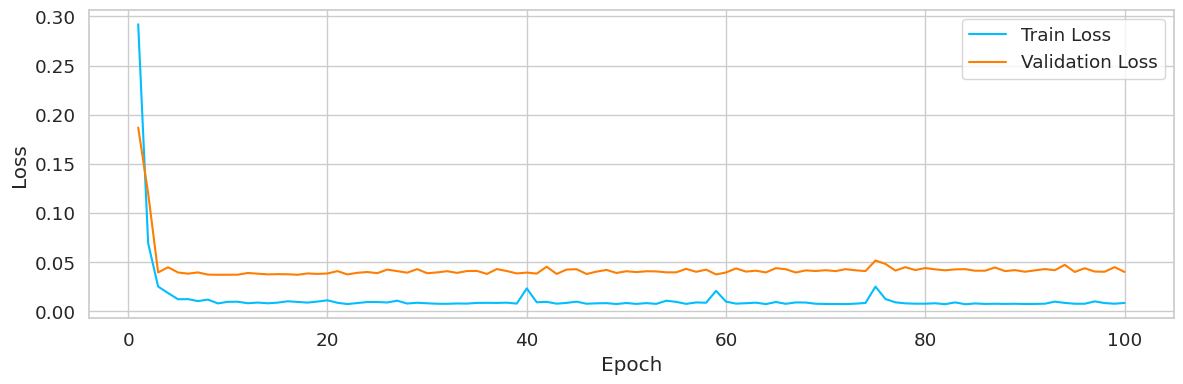

In [91]:
x = np.linspace(1, num_epochs, num_epochs)
plt.plot(x, train_hist, scalex=True, label='Train Loss')
plt.plot(x, val_hist, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 03 Forecasting and evaluate

In [ ]:
# num_forecast_steps = 14
# sequence_to_plot = X_test.squeeze().cpu().numpy()
# historical_data = sequence_to_plot[-1]

# forecasted_values = []
# with torch.no_grad():
#     for _ in range(num_forecast_steps):
#         historical_data_tensor = torch.as_tensor(historical_data).view(1, -1, 1).float().to(device)
#         predicted_value = model(historical_data_tensor).cpu().numpy()[0, 0]
#         forecasted_values.append(predicted_value)
#         historical_data = np.roll(historical_data, shift=-1)
#         historical_data[-1] = predicted_value

# last_date = X_test.index[-1]
# future_dates = pd.date_range(start=last_date + pd.DateOffset(1), periods=30)

# plt.rcParams['figure.figsize'] = [14, 4]
# plt.plot(X_test.index[-100:], X_test.Open[-100:], label="test_data", color="b")
# plt.plot(X_test.index[-30:], X_test.Open[-30:], label='actual values', color='green')
# plt.plot(X_test.index[-1:].append(future_dates), np.concatenate([X_test.Open[-1:], scaler.inverse_transform(np.array(forecasted_values).reshape(-1, 1)).flatten()]), label='forecasted values', color='red')

# plt.xlabel('Time Step')
# plt.ylabel('Value')
# plt.legend()
# plt.title('Time Series Forecasting')
# plt.grid(True)
# plt.show()

# # Evaluate the model and calculate RMSE and R² score
# model.eval()
# with torch.no_grad():
#     test_predictions = []
#     for batch_X_test in X_test:
#         batch_X_test = batch_X_test.to(device).unsqueeze(0)  # Add batch dimension
#         test_predictions.append(model(batch_X_test).cpu().numpy().flatten()[0])

# test_predictions = np.array(test_predictions)

# # Calculate RMSE and R² score
# rmse = np.sqrt(mean_squared_error(y_test.cpu().numpy(), test_predictions))
# r2 = r2_score(y_test.cpu().numpy(), test_predictions)

# print(f'RMSE: {rmse:.4f}')
# print(f'R² Score: {r2:.4f}')

RuntimeError: input.size(-1) must be equal to input_size. Expected 7, got 1

RMSE: 2.1688
R² Score: -0.0534


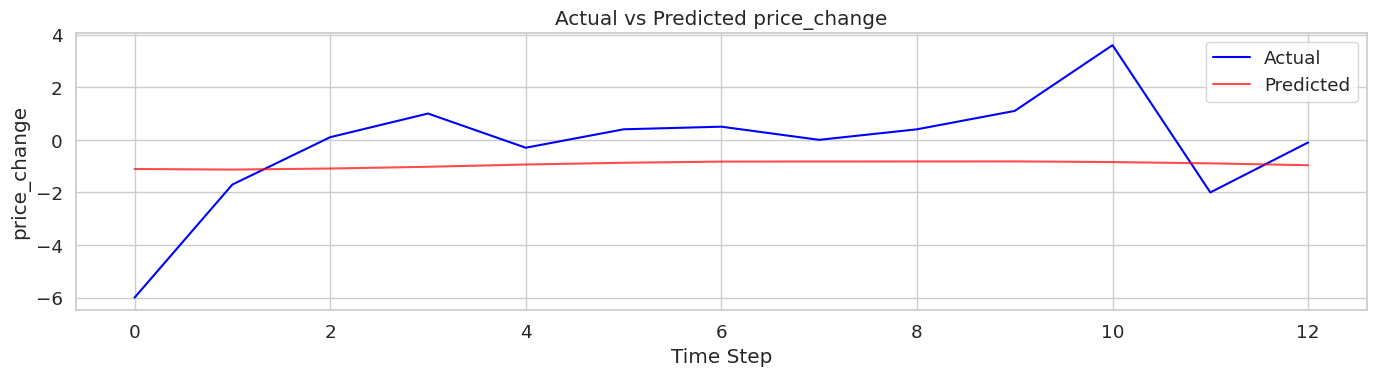

In [93]:
# Evaluate the model and calculate RMSE and R² score
model.eval()
with torch.no_grad():
    test_predictions = []
    for batch_X_test in X_test:
        batch_X_test = batch_X_test.to(device).unsqueeze(0)  # (1, seq_len, input_size)
        test_predictions.append(model(batch_X_test).cpu().numpy().flatten()[0])

test_predictions = np.array(test_predictions)
y_test_np = y_test.cpu().numpy().flatten()

# Inverse transform to original scale
y_scaler = MinMaxScaler()
y_scaler.fit(df_y_train.values.reshape(-1, 1))
y_test_inv = y_scaler.inverse_transform(y_test_np.reshape(-1, 1)).flatten()
pred_inv = y_scaler.inverse_transform(test_predictions.reshape(-1, 1)).flatten()

# Calculate RMSE and R² score
rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))
r2 = r2_score(y_test_inv, pred_inv)
print(f'RMSE: {rmse:.4f}')
print(f'R² Score: {r2:.4f}')

# Plot actual vs predicted
plt.rcParams['figure.figsize'] = [14, 4]
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(pred_inv, label='Predicted', color='red', alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel(predict_col)
plt.legend()
plt.title(f'Actual vs Predicted {predict_col}')
plt.grid(True)
plt.tight_layout()
plt.show()

## END